# **Install Required Packages**

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn nltk shap

# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score,recall_score,f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import nltk
import joblib
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt


# **Load Dataset**

In [3]:
df = pd.read_csv("/content/Mental-Health-Twitter.csv")
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


# **Preprocessing**

## **Basic Cleaning**

In [4]:
df.dropna(inplace=True)
df = df[df['label'].isin([0, 1])]

## **Text Cleaning**

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text.lower())
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['post_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label,clean_text
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1,year sinc diagnos anxieti depress today im tak...
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1,sunday need break im plan spend littl time pos...
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1,awak tire need sleep brain idea
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1,rt sewhq retro bear make perfect gift great be...
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1,hard say whether pack list make life easier re...


## **Feature Engineering**

In [7]:
df['text_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['retweets'] = df['retweets'].replace(' ', 0).astype(int)
df['followers'] = df['followers'].astype(int)
df['friends'] = df['friends'].astype(int)
df['favourites'] = df['favourites'].astype(int)
df['statuses'] = df['statuses'].astype(int)

## **Vectorization (TF-IDF)**

In [8]:
vectorizer = TfidfVectorizer(max_features=300)
X_text = vectorizer.fit_transform(df['clean_text']).toarray()
X_meta = df[['followers', 'friends', 'favourites', 'statuses', 'retweets', 'text_length', 'word_count']]

In [9]:
X = np.concatenate([X_text, X_meta.values], axis=1)
y = df['label']

# **Label Distribution**

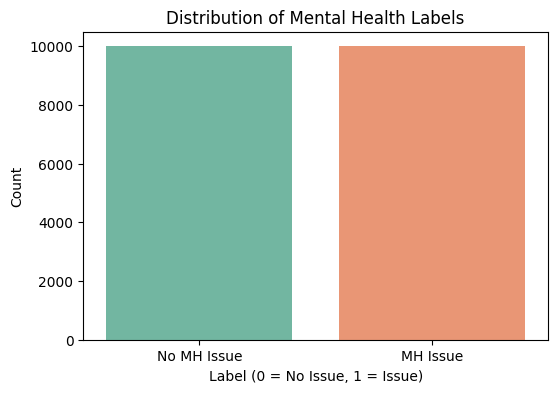

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Distribution of Mental Health Labels")
plt.xlabel("Label (0 = No Issue, 1 = Issue)")
plt.ylabel("Count")
plt.xticks([0,1], ['No MH Issue', 'MH Issue'])
plt.show()

# **Retweet Count Distribution**

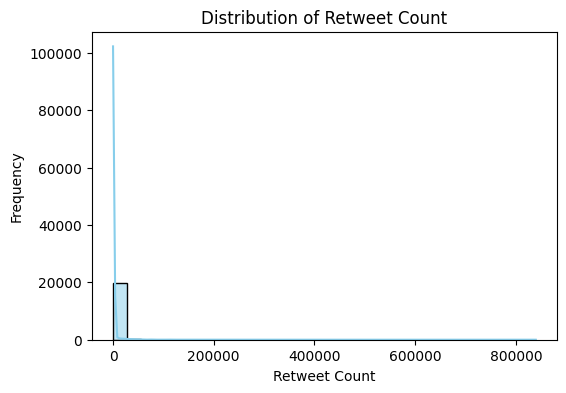

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['retweets'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Retweet Count")
plt.xlabel("Retweet Count")
plt.ylabel("Frequency")
plt.show()

# **Followers vs. Friends Scatter Plot**

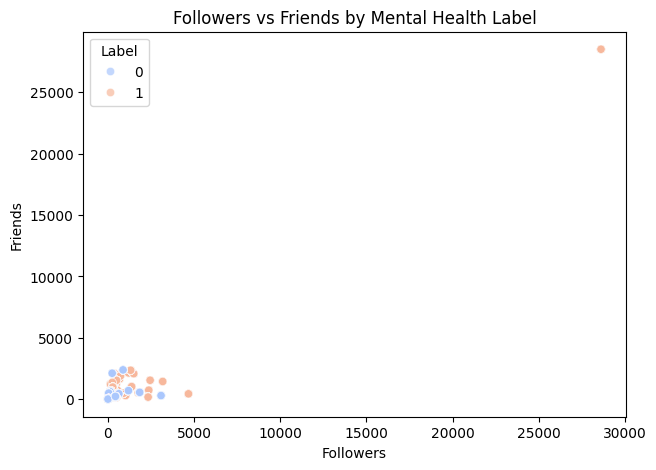

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='followers', y='friends', hue='label', data=df, palette='coolwarm', alpha=0.7)
plt.title("Followers vs Friends by Mental Health Label")
plt.xlabel("Followers")
plt.ylabel("Friends")
plt.legend(title="Label")
plt.show()

# **Word Cloud of All Cleaned Posts**

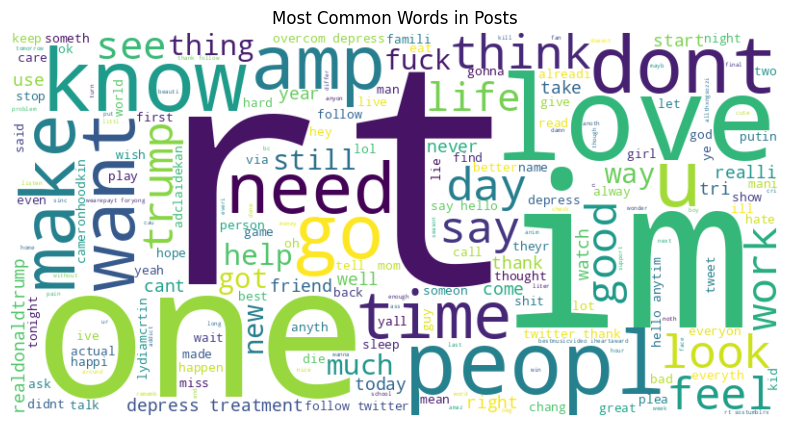

In [13]:
text = " ".join(post for post in df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Posts")
plt.show()

# **Text Length vs. Word Count (Scatter Plot)**

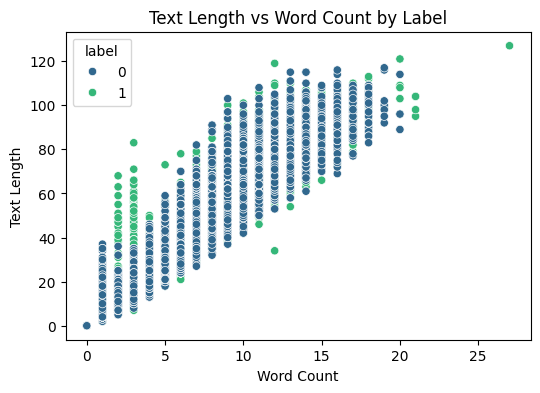

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='word_count', y='text_length', hue='label', data=df, palette='viridis')
plt.title("Text Length vs Word Count by Label")
plt.xlabel("Word Count")
plt.ylabel("Text Length")
plt.show()

# **Correlation Heatmap (Meta Features Only)**

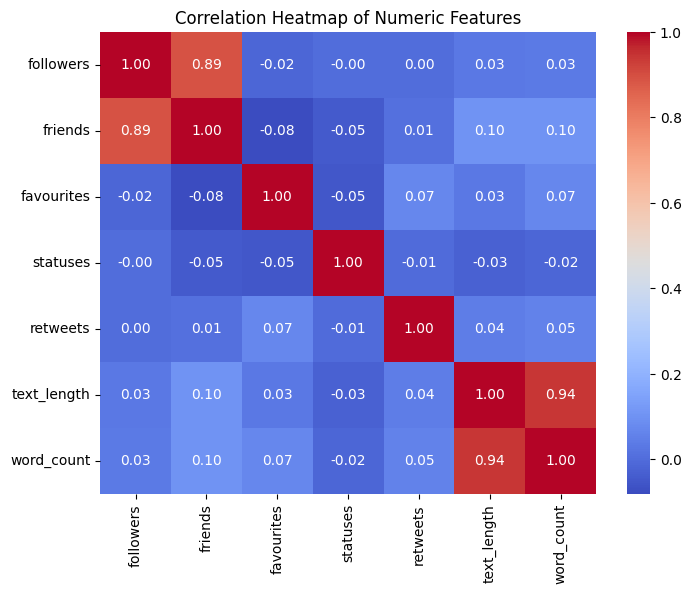

In [15]:
meta_cols = ['followers', 'friends', 'favourites', 'statuses', 'retweets', 'text_length', 'word_count']
corr = df[meta_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## **Train-Test Split + SMOTE**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# **Model Training & Evaluation**

## **Logistic Regression**

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)

In [19]:
acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

Accuracy: 0.8678
Precision: 0.8408
Recall: 0.9104
F1 Score: 0.8742


In [20]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1981
           1       0.84      0.91      0.87      2019

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



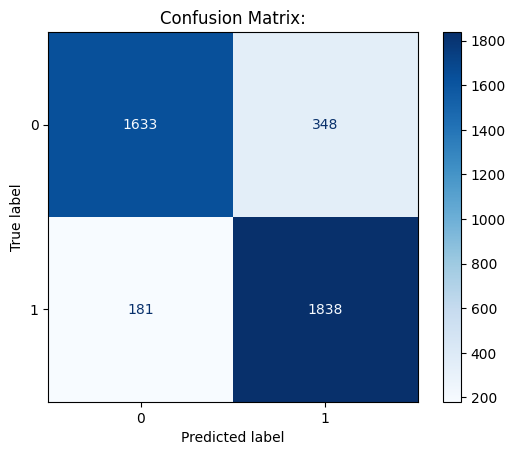

In [21]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title(f'Confusion Matrix:')
plt.show()

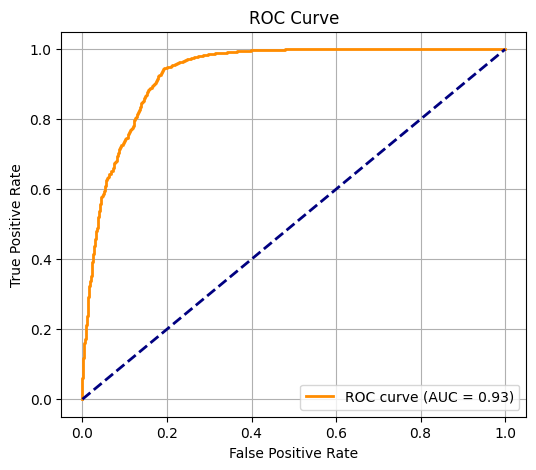

In [22]:
y_score = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## **Random Forest**

In [23]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

In [24]:
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      1.00      1.00      2019

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



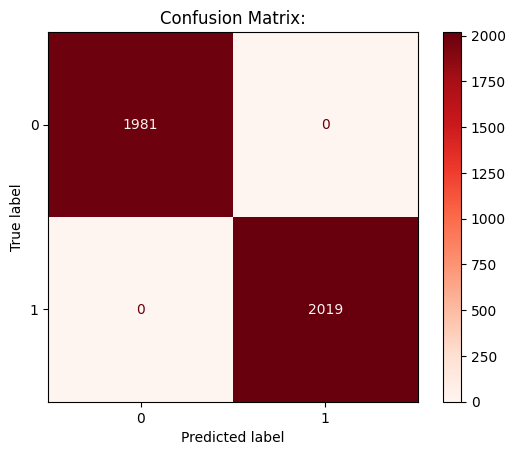

In [26]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds", values_format='d')
plt.title(f'Confusion Matrix:')
plt.show()

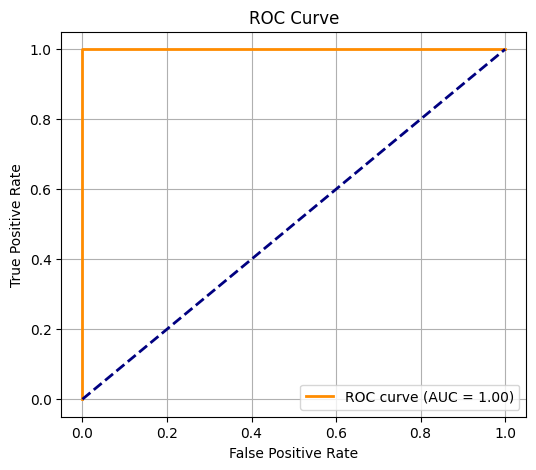

In [27]:
y_score = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## **XGBoost**

In [28]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)

In [29]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"Accuracy: {acc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [30]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      1.00      1.00      2019

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



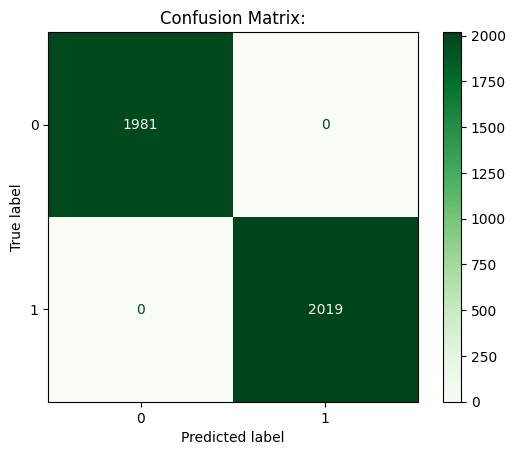

In [31]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens", values_format='d')
plt.title(f'Confusion Matrix:')
plt.show()

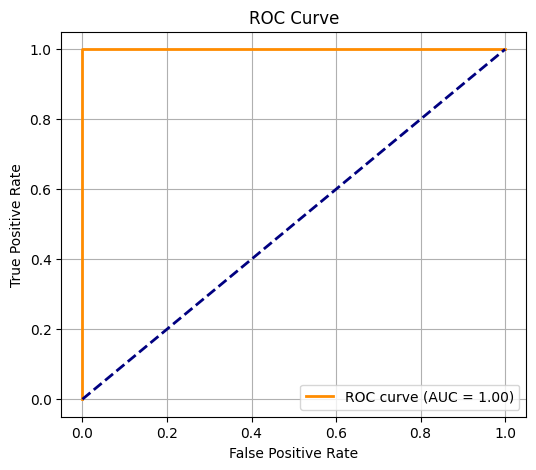

In [32]:
y_score = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Model Comparison

In [33]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [acc_lr, acc_rf, acc_xgb]
precision = [precision_lr, precision_rf, precision_xgb]
recall = [recall_lr, recall_rf, recall_xgb]
f1 = [f1_lr, f1_rf, f1_xgb]

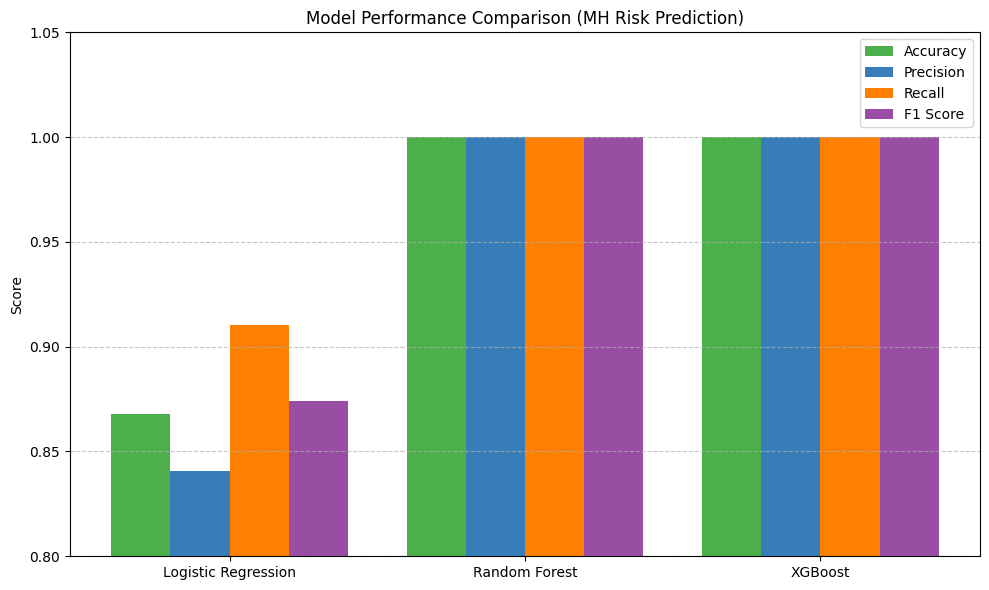

In [34]:
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 0.3, accuracy, width, label='Accuracy', color='#4daf4a')
plt.bar(x - 0.1, precision, width, label='Precision', color='#377eb8')
plt.bar(x + 0.1, recall, width, label='Recall', color='#ff7f00')
plt.bar(x + 0.3, f1, width, label='F1 Score', color='#984ea3')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Performance Comparison (MH Risk Prediction)')
plt.ylim(0.80, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
average_scores = [(a + p + r + f) / 4 for a, p, r, f in zip(accuracy, precision, recall, f1)]

best_index = average_scores.index(max(average_scores))
best_model_name = models[best_index]
best_score = average_scores[best_index]

print(f"Best Model: {best_model_name}")
print(f"Average Score: {best_score:.4f}")

Best Model: Random Forest
Average Score: 1.0000


# **Save Models**

In [36]:
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']